In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [2]:
from joblib import dump, load

market = load(project_root / "results/market_simulation.joblib")

In [3]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [4]:
scenario, r_m, last_r, last_vol = make_scenario(100, "weekly", market, 500, return_last=True)

In [5]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

In [6]:
scenarios = generate_scenarios(K, T, N, 'weekly', market, 500)

## MPC

In [7]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [456]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.2, trade=0.005, risk_type='semi_variance')

In [457]:
controller.is_QP_and_DPP()

(True, True)

In [3]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
from tqdm.notebook import tqdm

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):
        # NOTE: lasts are always daily for market, and market return is too
        actual_traj, market_return, last_r_m, last_vol =\
            make_scenario(n_steps, freq, market, 500, return_last=True)

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):
            if step == 0:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=500)
            else:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=0, 
                                                init_value=last_r_m.iloc[step-1], 
                                                init_vol=last_vol.iloc[step-1])
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve()
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.iloc[step]])

            MPC_sim.append(x_next)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.T, trading_cost=0.005)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 46:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 47:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 48:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 49:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 50:   0%|          | 0/52 [00:00<?, ?it/s]

## Results

In [459]:
from joblib import dump
dump(MPC_sims, project_root / "results/MPC_sims.joblib")
dump(market_sims, project_root / "results/market_sims.joblib")
dump(eq_sims, project_root / "results/eq_sims.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\eq_sims.joblib']

In [8]:
from joblib import load
MPC_sims = load(project_root / "results/MPC_sims.joblib")
market_sims = load(project_root / "results/market_sims.joblib")
eq_sims = load(project_root / "results/eq_sims.joblib")

In [9]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [259]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [260]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

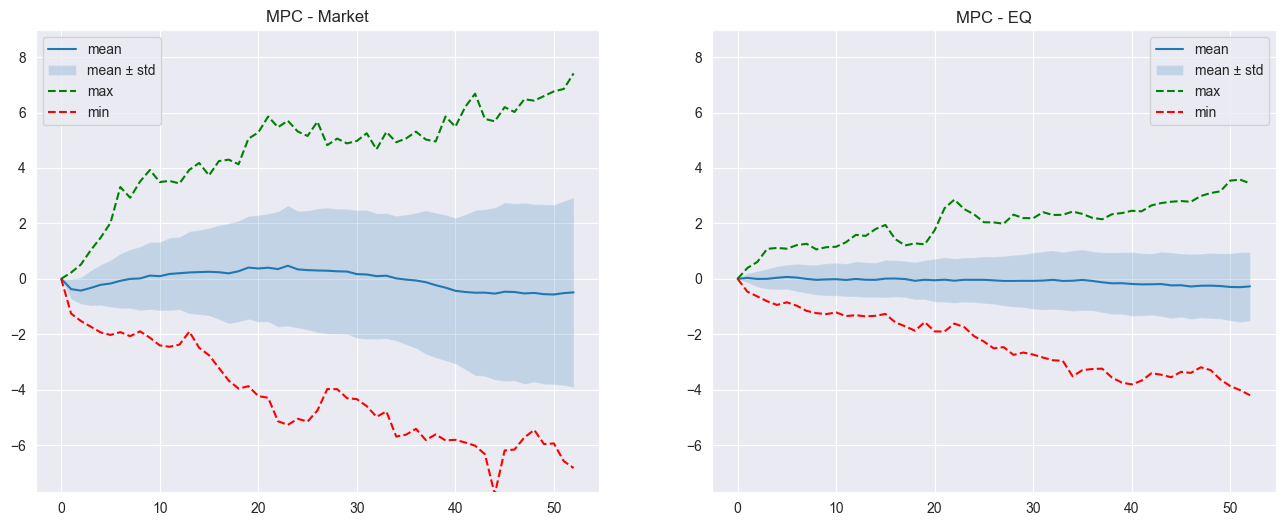

In [209]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

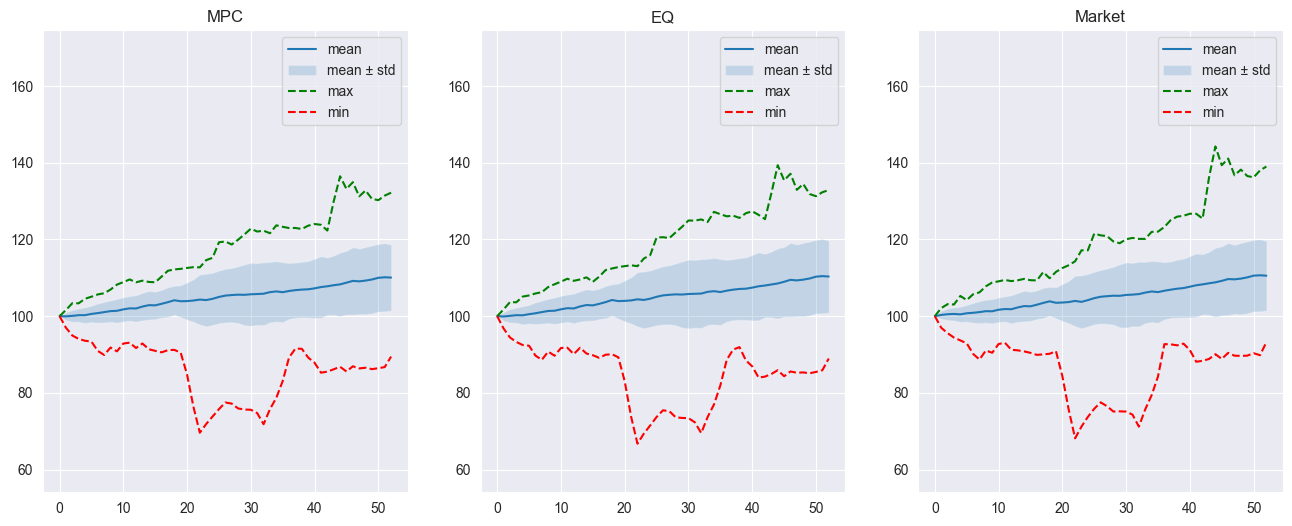

In [210]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [211]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [212]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [213]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

In [220]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [ ]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,0.000181,0.000591,0.000084,0.000040,inf,0.017881
MPC beta,0.866530,0.054082,0.007648,0.851160,0.881900,1.000000
EQ alpha,0.000072,0.000637,0.000090,-0.000079,inf,0.213444
EQ beta,0.948483,0.061906,0.008755,0.930889,0.966076,1.000000


In [261]:
metrics = compute_metrics(returns, rf)
metrics

,MPC,EQ,Market
mean of mean returns,0.001861,0.001914,0.001954
std of mean returns,0.001483,0.001612,0.001535
se of mean returns,0.000210,0.000228,0.000217
ci_low of mean returns,0.001439,0.001456,0.001518
ci high of mean returns,0.002282,0.002373,0.002391
mean of sharpe ratios,0.195260,0.180829,0.198840
std of sharpe ratios,0.145059,0.142238,0.152548
se of sharpe ratios,0.020514,0.020115,0.021573
ci_low of sharpe ratios,0.154035,0.140405,0.155486
ci high of sharpe ratios,0.236485,0.221252,0.242193
